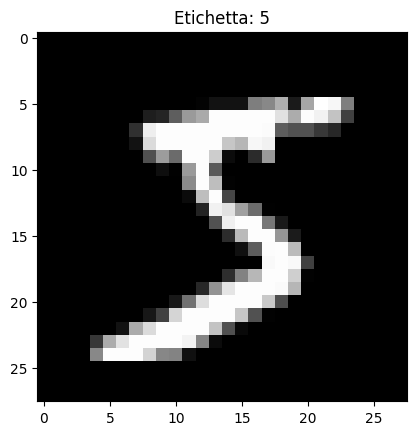

In [16]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import to_categorical
import matplotlib.pyplot as plt


# Caricamento del dataset MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Visualizzazione di un esempio

plt.imshow(X_train[0], cmap='gray')

plt.title(f'Etichetta: {y_train[0]}')

plt.show()


# Normalizzazione dei dati, le reti neurali funzionano solo con dato normalizzati
# 255 numero di pixel totali

X_train = X_train.astype('float32') / 255

X_test = X_test.astype('float32') / 255


# Reshape dei dati

X_train = X_train.reshape(-1, 28*28)

X_test = X_test.reshape(-1, 28*28)


# Conversione delle etichette in formato one-hot encoding

y_train = to_categorical(y_train, num_classes=10)

y_test = to_categorical(y_test, num_classes=10)

In [17]:
# Creazione del modello

model = Sequential()


# Aggiunta degli strati

model.add(Dense(units=128, activation='relu', input_shape=(784,)))

model.add(Dense(units=64, activation='relu'))

model.add(Dense(units=10, activation='softmax'))

C:\Users\elisabetta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam',

loss='categorical_crossentropy',

metrics=['accuracy'])

In [20]:
history = model.fit(X_train, y_train,

    epochs=20,   ##10, 

    batch_size=32,

    validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9238 - loss: 0.2589 - val_accuracy: 0.9692 - val_loss: 0.1114
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9666 - loss: 0.1080 - val_accuracy: 0.9748 - val_loss: 0.0787
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9764 - loss: 0.0758 - val_accuracy: 0.9725 - val_loss: 0.0900
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9815 - loss: 0.0566 - val_accuracy: 0.9782 - val_loss: 0.0741
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9857 - loss: 0.0453 - val_accuracy: 0.9797 - val_loss: 0.0710
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9880 - loss: 0.0365 - val_accuracy: 0.9772 - val_loss: 0.0806
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9903 - loss: 0.0288 - val_accuracy: 0.9760 - val_loss: 0.0946
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9922 - loss: 0.0241 - 

In [21]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Perdita sul test set: {test_loss:.4f}')

print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9790 - loss: 0.1124
Perdita sul test set: 0.1124
Accuratezza sul test set: 0.9790


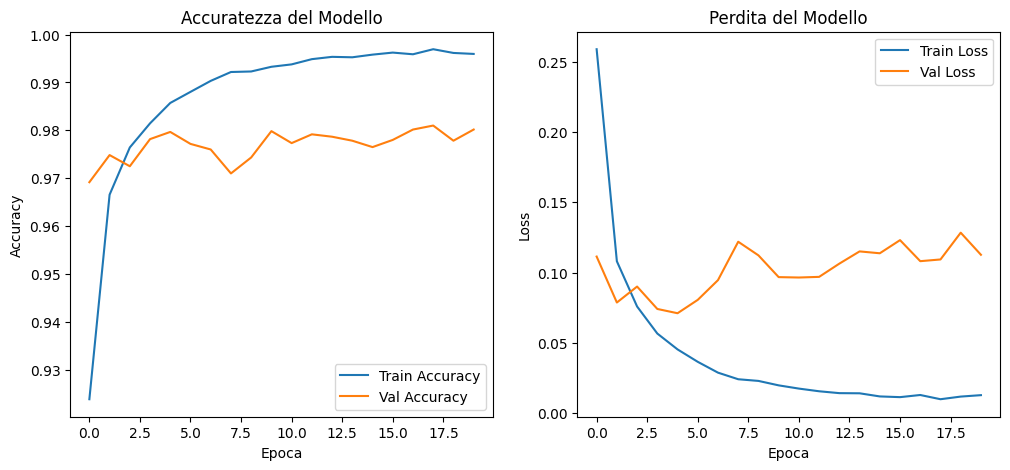

In [22]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()